In [8]:
import pandas as pd

# Load the datasets from the specified paths
df_corona = pd.read_csv("../data cleanup/sars_cov2_cdr_seq.tsv", sep="\t")
df_human = pd.read_csv("../data cleanup/human_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("../data cleanup/influenza_cdr_seq.tsv", sep="\t")



In [9]:
def compute_aa_composition(df, colname, group_label):
    aac = df[colname].apply(aa_composition).apply(pd.Series)
    aac["group"] = group_label
    return aac


## Code für balkendiagramme für Aminosäurezusammensetzung

In [10]:
aa_1_to_3 = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val'
}

def compute_aa_composition(df, colname, group_label):
    aac = df[colname].apply(aa_composition).apply(pd.Series)
    aac["group"] = group_label
    return aac

def plot_aa_composition(aac_sars, aac_influenza, aac_human, region_label="CDR-H3"):
    # Mittelwerte
    mean_sars = aac_sars.drop(columns="group").mean()
    mean_influenza = aac_influenza.drop(columns="group").mean()
    mean_human = aac_human.drop(columns="group").mean()

    df_plot = pd.DataFrame({
        "AminoAcid": mean_sars.index,
        "Corona": mean_sars.values,
        "Influenza": mean_influenza.values,
        "Human": mean_human.values
    })

    # Plot
    import matplotlib.pyplot as plt
    import numpy as np

    x = np.arange(len(df_plot["AminoAcid"]))
    width = 0.25

    plt.figure(figsize=(12, 6))
    plt.bar(x - width, df_plot["Corona"], width=width, label="Corona", color="pink")
    plt.bar(x,         df_plot["Influenza"], width=width, label="Influenza", color="mediumpurple")
    plt.bar(x + width, df_plot["Human"], width=width, label="Human", color="skyblue")

    aa_labels_3 = [aa_1_to_3[aa] for aa in df_plot["AminoAcid"]]
    plt.xticks(ticks=x, labels=aa_labels_3)
    plt.ylabel("Relative Häufigkeit")
    plt.xlabel("Aminosäure")
    plt.title(f"Aminosäurezusammensetzung in {region_label}")
    plt.ylim(0, 0.25)  # Fixiere Y-Achse auf Bereich 0 bis 0.25

    plt.legend()
    plt.tight_layout()
    plt.show()


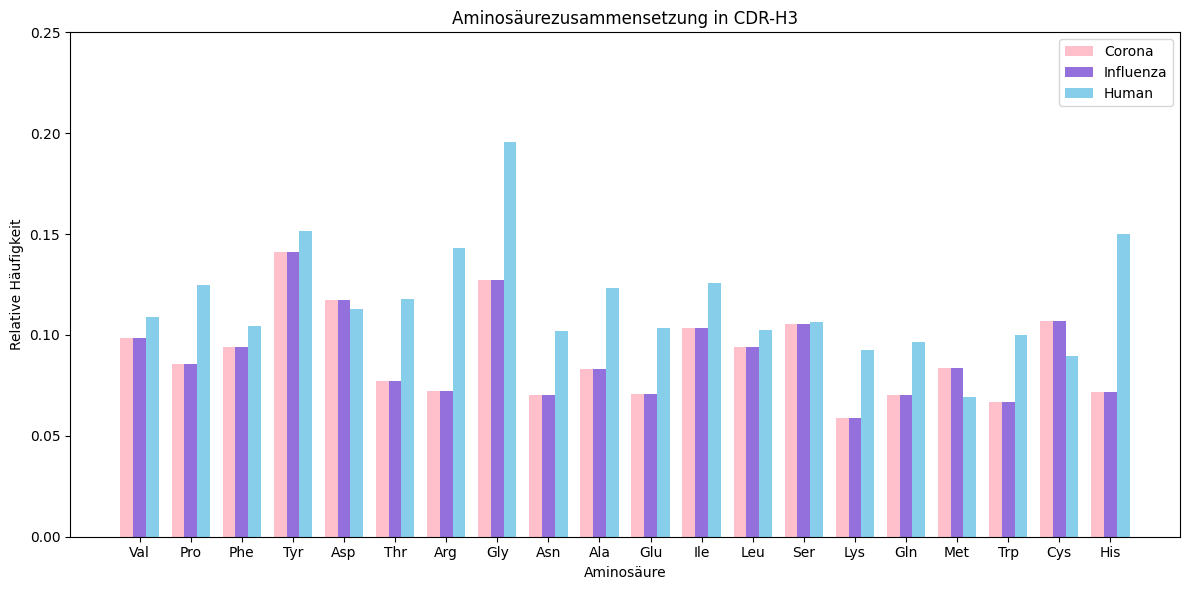

In [11]:
aac_sars_h3 = compute_aa_composition(df_corona, "CDR_H3", "Corona")
aac_influenza_h3 = compute_aa_composition(df_influenza, "CDR_H3", "Influenza")
aac_human_h3 = compute_aa_composition(df_human, "CDR_H3", "Human")

plot_aa_composition(aac_sars_h3, aac_influenza_h3, aac_human_h3, region_label="CDR-H3")


In [12]:
aac_sars_h2 = compute_aa_composition(df_corona, "CDR_H2", "Corona")
aac_influenza_h2 = compute_aa_composition(df_influenza, "CDR_H2", "Influenza")
aac_human_h2 = compute_aa_composition(df_human, "CDR_H2", "Human")

plot_aa_composition(aac_sars_h2, aac_influenza_h2, aac_human_h2, region_label="CDR-H2")


ValueError: All arrays must be of the same length

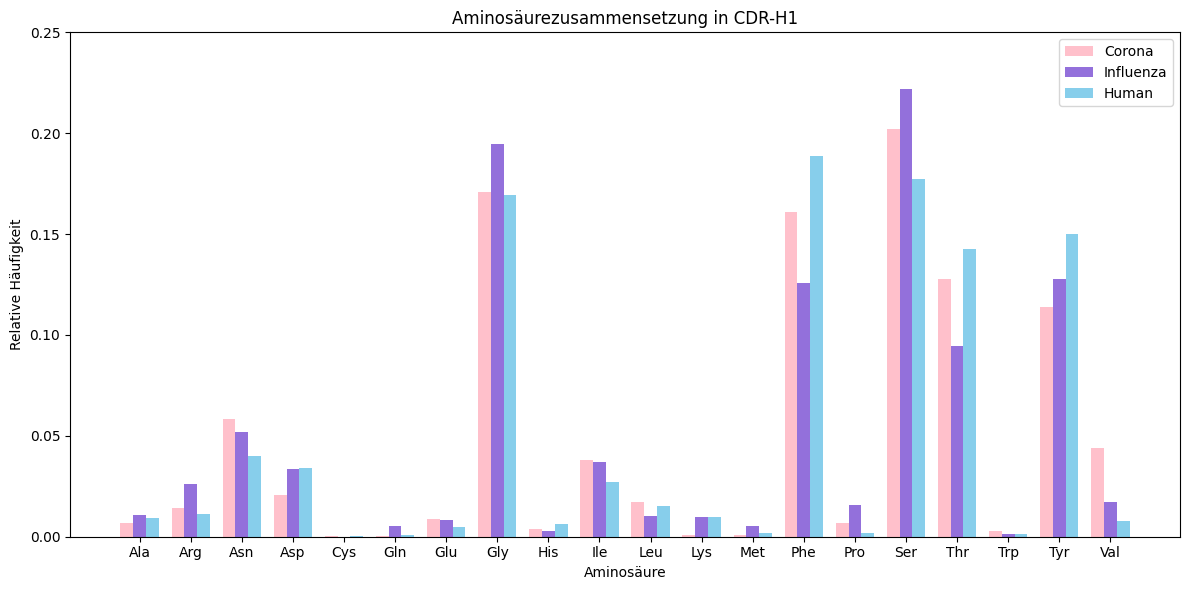

In [ ]:
aac_sars_h1 = compute_aa_composition(df_corona, "CDR_H1", "Corona")
aac_influenza_h1 = compute_aa_composition(df_influenza, "CDR_H1", "Influenza")
aac_human_h1 = compute_aa_composition(df_human, "CDR_H1", "Human")

plot_aa_composition(aac_sars_h1, aac_influenza_h1, aac_human_h1, region_label="CDR-H1")



 Generating plot for CDR_H1...


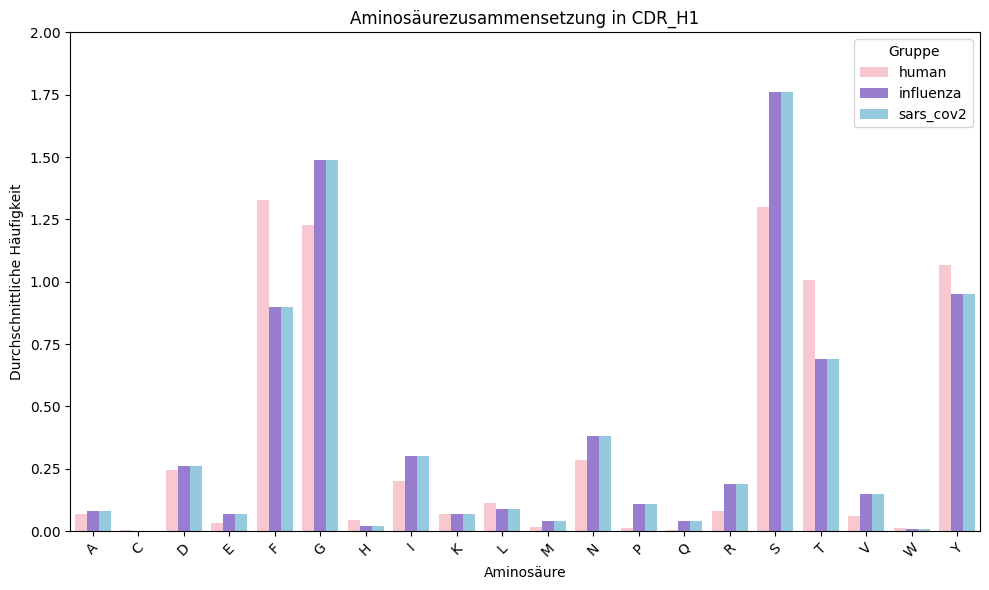


 Generating plot for CDR_H2...


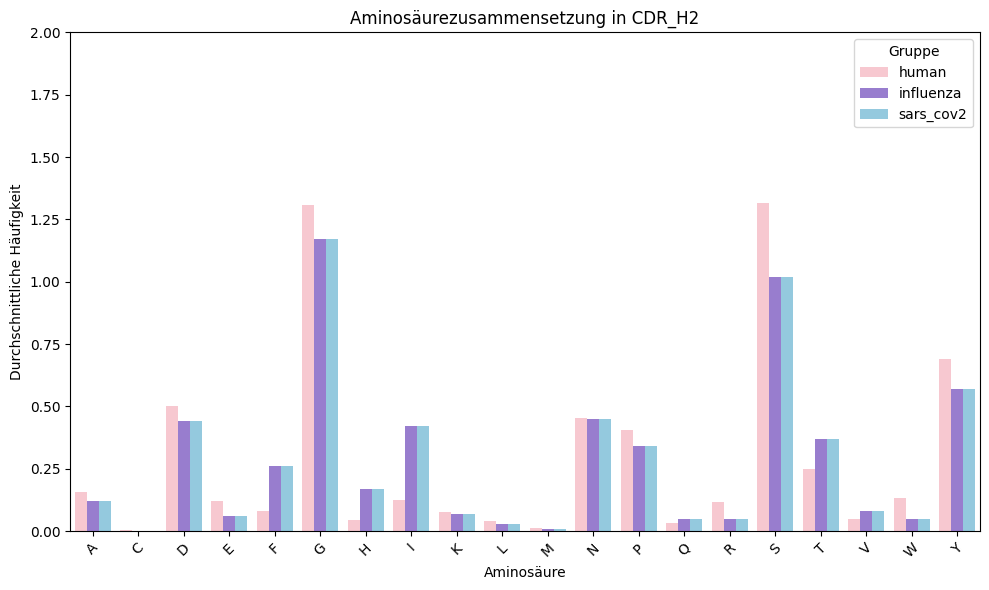


 Generating plot for CDR_H3...


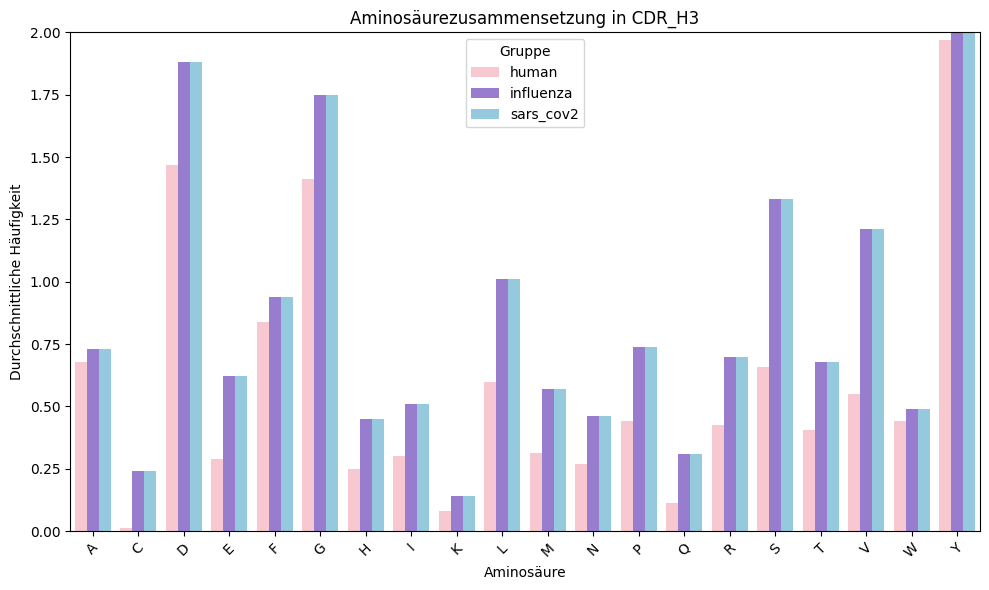

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the combined dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# List of amino acids
amino_acids = [
    "A", "R", "N", "D", "C", "Q", "E", "G", "H", "I",
    "L", "K", "M", "F", "P", "S", "T", "W", "Y", "V"
]

# Loop over all CDR regions
for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f"\n Generating plot for {cdr}...")

    # Prepare data for plotting
    count_cols = [f"{cdr}_count_{aa}" for aa in amino_acids]
    plot_df = df[["source"] + count_cols]
    plot_df = plot_df.melt(id_vars="source", var_name="AminoAcid", value_name="Count")
    plot_df["AminoAcid"] = plot_df["AminoAcid"].str.replace(f"{cdr}_count_", "")

    # Calculate mean frequency per group and amino acid
    mean_df = plot_df.groupby(["source", "AminoAcid"])["Count"].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=mean_df, x="AminoAcid", y="Count", hue="source", palette=["pink", "mediumpurple", "skyblue"])
    plt.title(f"Aminosäurezusammensetzung in {cdr}")    
    plt.xlabel("Aminosäure")
    plt.ylabel("Durchschnittliche Häufigkeit")
    plt.ylim(0, 2)  # Fixiere Y-Achse auf Bereich 0 bis 0.25
    plt.legend(title="Gruppe")  
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    


C:\Users\082mi\AppData\Local\Temp\ipykernel_22988\2022203506.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lengths, x="group", y="length", palette=["pink", "mediumpurple", "skyblue"])


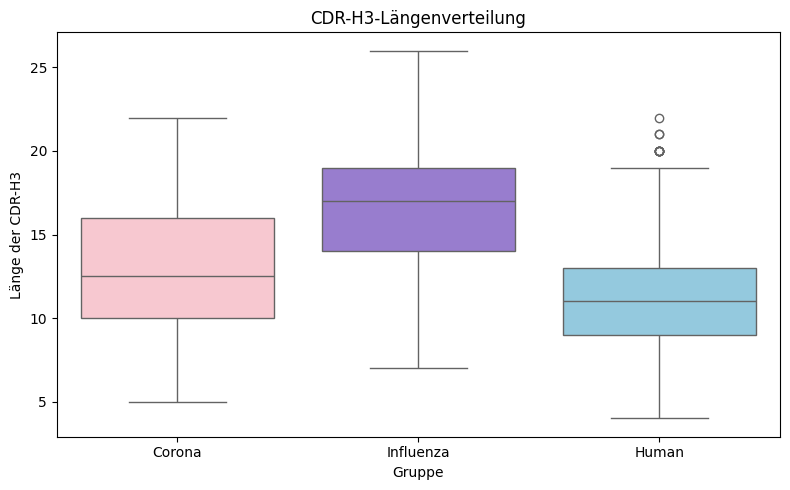

In [ ]:
import pandas as pd
# Load the datasets


df_corona["length"] = df_corona["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_corona["group"] = "Corona"

df_influenza["length"] = df_influenza["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_influenza["group"] = "Influenza"

df_human["length"] = df_human["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_human["group"] = "Human"

df_lengths = pd.concat([df_corona, df_influenza, df_human], ignore_index=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_lengths, x="group", y="length", palette=["pink", "mediumpurple", "skyblue"])
plt.title("CDR-H3-Längenverteilung")
plt.ylabel("Länge der CDR-H3")
plt.xlabel("Gruppe")
plt.tight_layout()
plt.show()



In [ ]:
def compute_zscore_df(aac_df):
    df = aac_df.drop(columns="group")
    mean = df.mean()
    std = df.std()
    z_df = (df - mean) / std
    z_df["group"] = aac_df["group"].values
    return z_df


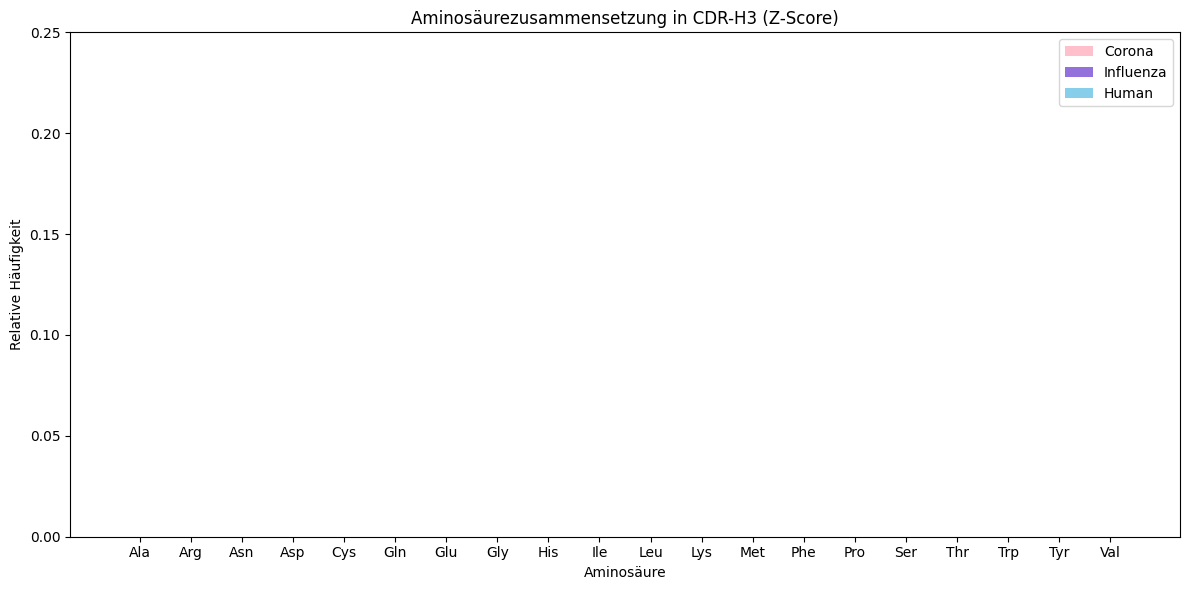

In [ ]:
# Z-Score normalisieren
z_sars_h3 = compute_zscore_df(aac_sars_h3)
z_influenza_h3 = compute_zscore_df(aac_influenza_h3)
z_human_h3 = compute_zscore_df(aac_human_h3)

# Plotten mit Z-Scores
plot_aa_composition(z_sars_h3, z_influenza_h3, z_human_h3, region_label="CDR-H3 (Z-Score)")


In [ ]:
#%pip install statsmodels

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def test_pairwise_aa_composition(aac1, aac2, label1="Corona", label2="Influenza"):
    aa_columns = [col for col in aac1.columns if col != "group"]
    results = []

    for aa in aa_columns:
        group1_vals = aac1[aa]
        group2_vals = aac2[aa]

        stat, p = mannwhitneyu(group1_vals, group2_vals, alternative="two-sided")
        results.append({
            "AminoAcid": aa,
            f"Mean_{label1}": group1_vals.mean(),
            f"Mean_{label2}": group2_vals.mean(),
            "p_value": p
        })

    df_result = pd.DataFrame(results).sort_values("p_value")
    df_result["adjusted_p"] = multipletests(df_result["p_value"], method="fdr_bh")[1]
    return df_result

results_pairwise = test_pairwise_aa_composition(aac_sars_h3, aac_influenza_h3, "Corona", "Influenza")
print(results_pairwise)


   AminoAcid  Mean_Corona  Mean_Influenza   p_value  adjusted_p
3          D     0.149148        0.110155  0.000008    0.000164
1          R     0.030595        0.041835  0.001045    0.010454
8          H     0.020008        0.028645  0.003065    0.015749
7          G     0.133580        0.106963  0.003150    0.015749
5          Q     0.011860        0.018267  0.007327    0.029308
16         T     0.031285        0.042495  0.011792    0.039305
2          N     0.019284        0.027486  0.014464    0.041326
6          E     0.029395        0.037520  0.018852    0.047129
11         K     0.004648        0.007657  0.023351    0.050632
19         V     0.060986        0.071805  0.025316    0.050632
15         S     0.065496        0.078035  0.041074    0.074681
12         M     0.025625        0.034325  0.071187    0.118645
18         Y     0.142099        0.118665  0.105311    0.162017
14         P     0.034944        0.042723  0.131350    0.187643
17         W     0.024479        0.02867

In [ ]:
results_pairwise = test_pairwise_aa_composition(aac_sars_h2, aac_influenza_h2, "Corona", "Influenza")
print(results_pairwise)

   AminoAcid  Mean_Corona  Mean_Influenza       p_value    adjusted_p
13         F     0.009965        0.045667  6.714984e-09  1.342997e-07
8          H     0.010141        0.033000  9.922866e-05  9.922866e-04
16         T     0.038205        0.062167  8.331342e-04  5.116422e-03
9          I     0.042218        0.070333  1.023284e-03  5.116422e-03
15         S     0.229456        0.181012  4.037775e-03  1.615110e-02
7          G     0.240278        0.207500  6.530732e-02  2.176911e-01
10         L     0.012522        0.005000  8.593363e-02  2.455247e-01
18         Y     0.120093        0.103036  1.050153e-01  2.625382e-01
17         W     0.017045        0.008012  1.347494e-01  2.994432e-01
11         K     0.006507        0.011345  1.619237e-01  3.238473e-01
19         V     0.010913        0.013583  2.200496e-01  4.000902e-01
5          Q     0.004850        0.008667  2.959215e-01  4.932025e-01
1          R     0.005933        0.007679  4.909843e-01  7.553604e-01
3          D     0.0

In [ ]:
results_pairwise = test_pairwise_aa_composition(aac_sars_h1, aac_influenza_h1, "Corona", "Influenza")
print(results_pairwise)

   AminoAcid  Mean_Corona  Mean_Influenza   p_value  adjusted_p
16         T     0.127739        0.094484  0.000055    0.001102
11         K     0.000966        0.009603  0.000156    0.001273
19         V     0.043986        0.017302  0.000191    0.001273
5          Q     0.000378        0.005536  0.001126    0.005631
13         F     0.160703        0.125754  0.003295    0.013181
3          D     0.020770        0.033651  0.006985    0.023285
7          G     0.170818        0.194702  0.008731    0.024944
1          R     0.014193        0.026190  0.016615    0.040045
12         M     0.001050        0.005079  0.018020    0.040045
14         P     0.006965        0.015714  0.026518    0.053036
2          N     0.058443        0.051944  0.068782    0.125058
18         Y     0.113909        0.127599  0.179279    0.298799
0          A     0.006713        0.010794  0.249759    0.384245
15         S     0.202144        0.222083  0.328920    0.469885
10         L     0.017049        0.01011

In [ ]:
results_pairwise = test_pairwise_aa_composition(aac_sars_h3, aac_human_h3, "Corona", "Influenza")
print(results_pairwise)

   AminoAcid  Mean_Corona  Mean_Influenza       p_value  adjusted_p
4          C     0.010928        0.000792  5.042866e-08    0.000001
18         Y     0.142099        0.168410  5.309221e-04    0.004319
17         W     0.024479        0.038795  6.479192e-04    0.004319
3          D     0.149148        0.130791  1.123989e-03    0.005620
13         F     0.064234        0.078215  7.683571e-03    0.028506
15         S     0.065496        0.054664  8.551847e-03    0.028506
6          E     0.029395        0.023476  1.201698e-02    0.032486
9          I     0.034186        0.027007  1.299457e-02    0.032486
19         V     0.060986        0.047487  2.823297e-02    0.062740
0          A     0.049640        0.059542  6.333370e-02    0.126667
7          G     0.133580        0.125386  9.778168e-02    0.163961
10         L     0.057580        0.050731  9.837655e-02    0.163961
5          Q     0.011860        0.008724  1.152502e-01    0.177308
11         K     0.004648        0.005306  3.605

In [ ]:
results_pairwise = test_pairwise_aa_composition(aac_sars_h2, aac_human_h2, "Corona", "Influenza")
print(results_pairwise)

   AminoAcid  Mean_Corona  Mean_Influenza   p_value  adjusted_p
1          R     0.005933        0.018878  0.000039    0.000789
18         Y     0.120093        0.117018  0.007821    0.078210
6          E     0.012676        0.019635  0.020448    0.092854
7          G     0.240278        0.222198  0.020595    0.092854
14         P     0.052557        0.067898  0.023214    0.092854
10         L     0.012522        0.007036  0.034746    0.115819
9          I     0.042218        0.020822  0.047228    0.134938
11         K     0.006507        0.011556  0.056610    0.141524
15         S     0.229456        0.224340  0.143713    0.292767
0          A     0.017262        0.026278  0.146384    0.292767
12         M     0.000882        0.002199  0.256833    0.403248
13         F     0.009965        0.013482  0.258374    0.403248
17         W     0.017045        0.023407  0.262111    0.403248
4          C     0.000000        0.000440  0.319232    0.456045
16         T     0.038205        0.04188

In [ ]:
results_pairwise = test_pairwise_aa_composition(aac_human_h2, aac_human_h3, "Corona", "Influenza")
print(results_pairwise)

   AminoAcid  Mean_Corona  Mean_Influenza       p_value    adjusted_p
13         F     0.013482        0.078215  3.536694e-47  7.073387e-46
15         S     0.224340        0.054664  1.533937e-43  1.533937e-42
19         V     0.008534        0.047487  1.802870e-33  1.103597e-32
10         L     0.007036        0.050731  2.207193e-33  1.103597e-32
7          G     0.222198        0.125386  7.103828e-26  2.841531e-25
12         M     0.002199        0.026358  5.681636e-25  1.893879e-24
0          A     0.026278        0.059542  3.866347e-20  1.104671e-19
3          D     0.086456        0.130791  7.335567e-19  1.833892e-18
18         Y     0.117018        0.168410  6.648334e-12  1.477408e-11
17         W     0.023407        0.038795  9.426278e-12  1.885256e-11
1          R     0.018878        0.035931  4.235510e-10  7.700928e-10
8          H     0.008004        0.020013  5.484726e-10  9.141210e-10
2          N     0.074764        0.024157  1.173759e-08  1.805783e-08
9          I     0.0

## AAC nach Gruppen

In [ ]:
aa_properties = {
    'A': 'unpolar',  # Ala
    'V': 'unpolar',  # Val
    'L': 'unpolar',  # Leu
    'I': 'unpolar',  # Ile
    'M': 'unpolar',  # Met
    'F': 'aromatisch',  # Phe
    'W': 'aromatisch',  # Trp
    'P': 'unpolar',  # Pro
    'G': 'unpolar',  # Gly
    'C': 'polar',    # Cys (schwach polar)

    'S': 'polar',    # Ser
    'T': 'polar',    # Thr
    'N': 'polar',    # Asn
    'Q': 'polar',    # Gln
    'Y': 'aromatisch',  # Tyr (polar, aber aromatisch)

    'K': 'basisch',  # Lys
    'R': 'basisch',  # Arg
    'H': 'basisch',  # His

    'D': 'sauer',    # Asp
    'E': 'sauer'     # Glu
}

def group_by_property(row):
    grouped = {'unpolar': 0, 'polar': 0, 'sauer': 0, 'basisch': 0, 'aromatisch': 0}
    for aa, freq in row.items():
        if aa in aa_properties:
            prop = aa_properties[aa]
            grouped[prop] += freq
    return pd.Series(grouped)


# Group by properties for CDR-H3
aac_sars_props_h3 = aac_sars_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h3["group"] = "Corona"
aac_influenza_props_h3 = aac_influenza_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h3["group"] = "Influenza"
aac_human_props_h3 = aac_human_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h3["group"] = "Human"

# Group by properties for CDR-H2
aac_sars_props_h2 = aac_sars_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h2["group"] = "Corona"    
aac_influenza_props_h2 = aac_influenza_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h2["group"] = "Influenza"
aac_human_props_h2 = aac_human_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h2["group"] = "Human"

# Group by properties for CDR-H1
aac_sars_props_h1 = aac_sars_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h1["group"] = "Corona"       
aac_influenza_props_h1 = aac_influenza_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h1["group"] = "Influenza"   
aac_human_props_h1 = aac_human_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h1["group"] = "Human"



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_property_groups(aac_sars, aac_influenza, aac_human, region_label="CDR-H3"):
    # Gruppierung nach chemischen Eigenschaften
    def group_by_property(row):
        aa_properties = {
            'A': 'unpolar', 'V': 'unpolar', 'L': 'unpolar', 'I': 'unpolar', 'M': 'unpolar',
            'F': 'aromatisch', 'W': 'aromatisch', 'P': 'unpolar', 'G': 'unpolar', 'C': 'polar',
            'S': 'polar', 'T': 'polar', 'N': 'polar', 'Q': 'polar', 'Y': 'aromatisch',
            'K': 'basisch', 'R': 'basisch', 'H': 'basisch',
            'D': 'sauer', 'E': 'sauer'
        }
        grouped = {'unpolar': 0, 'polar': 0, 'sauer': 0, 'basisch': 0, 'aromatisch': 0}
        for aa, freq in row.items():
            if aa in aa_properties:
                grouped[aa_properties[aa]] += freq
        return pd.Series(grouped)

    # Anwendung auf alle Gruppen
    props_sars = aac_sars.drop(columns="group").apply(group_by_property, axis=1)
    props_influenza = aac_influenza.drop(columns="group").apply(group_by_property, axis=1)
    props_human = aac_human.drop(columns="group").apply(group_by_property, axis=1)

    # Mittelwerte berechnen
    mean_sars = props_sars.mean()
    mean_influenza = props_influenza.mean()
    mean_human = props_human.mean()

    # Plot-DataFrame
    df_props_plot = pd.DataFrame({
        "Eigenschaft": mean_sars.index,
        "Corona": mean_sars.values,
        "Influenza": mean_influenza.values,
        "Human": mean_human.values
    })

    # Balkendiagramm
    x = np.arange(len(df_props_plot["Eigenschaft"]))
    width = 0.25

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, df_props_plot["Corona"], width=width, label="Corona", color="pink")
    plt.bar(x,         df_props_plot["Influenza"], width=width, label="Influenza", color="mediumpurple")
    plt.bar(x + width, df_props_plot["Human"], width=width, label="Human", color="skyblue")

    plt.xticks(ticks=x, labels=df_props_plot["Eigenschaft"])
    plt.ylabel("Relative Häufigkeit der Aminosäuregruppen")
    plt.xlabel("Aminosäuregruppe")
    plt.title(f"Eigenschaften der Aminosäuren in {region_label}")
    plt.ylim(0, 0.40)  # Fixiere Y-Achse auf Bereich 0 bis 0.40
    plt.legend()
    plt.tight_layout()
    plt.show()


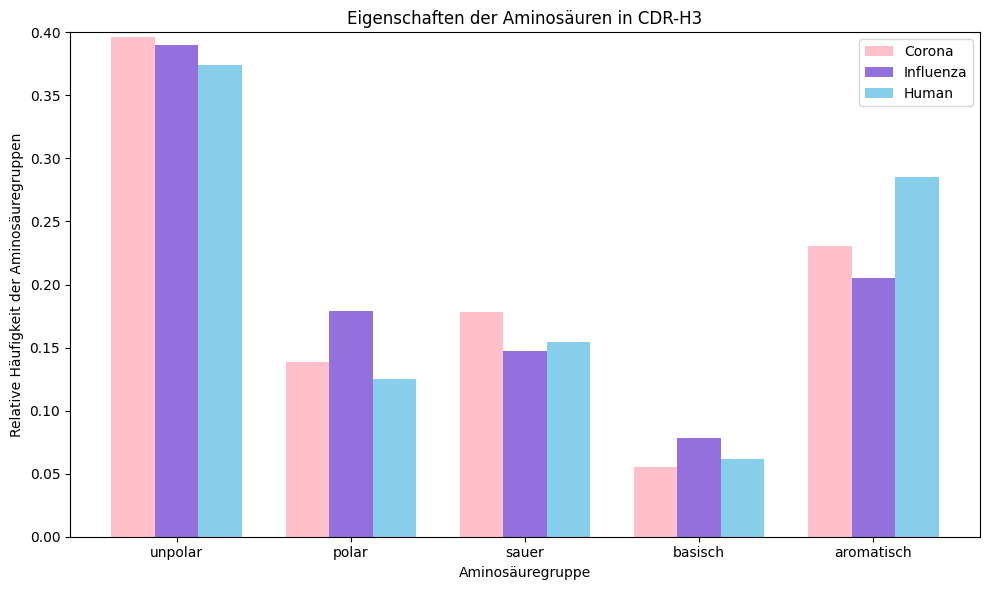

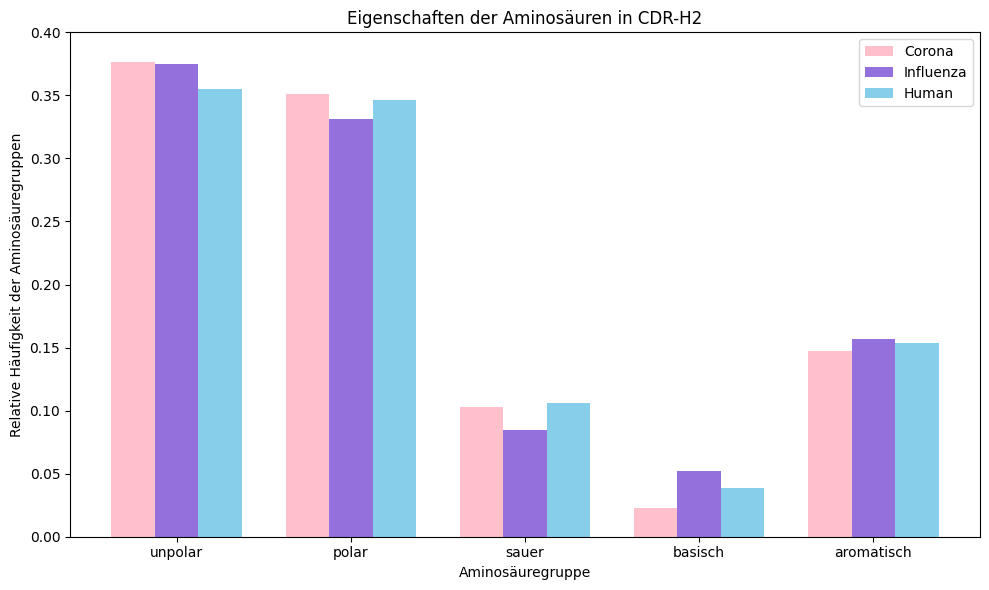

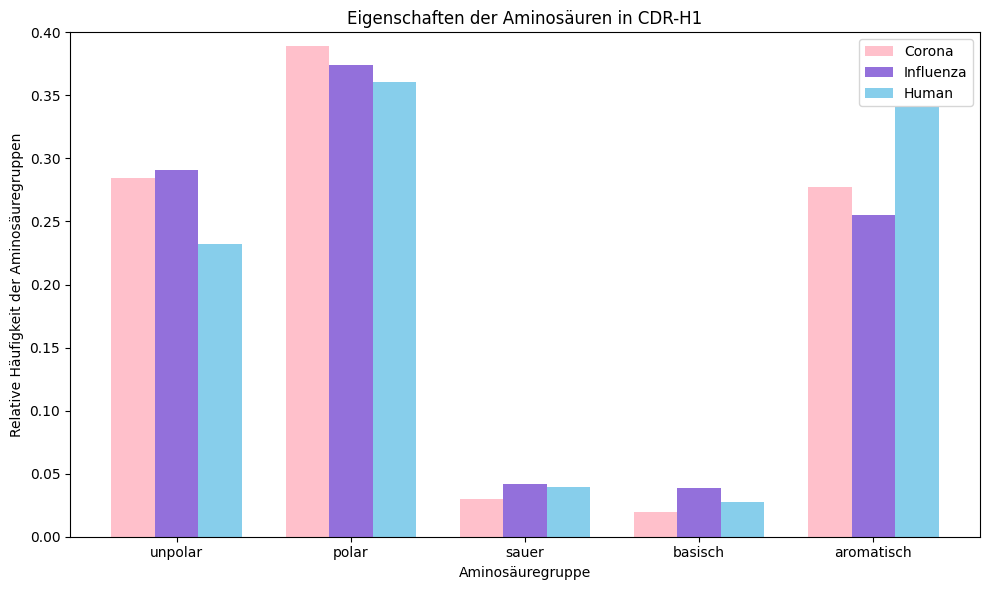

In [ ]:
plot_property_groups(aac_sars_h3, aac_influenza_h3, aac_human_h3, region_label="CDR-H3")
plot_property_groups(aac_sars_h2, aac_influenza_h2, aac_human_h2, region_label="CDR-H2")
plot_property_groups(aac_sars_h1, aac_influenza_h1, aac_human_h1, region_label="CDR-H1")


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the combined dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# Loop over all CDR regions
for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f"\n Generating heatmap for {cdr}...")
    
    # Find columns that count amino acids for this CDR
    aa_columns = [col for col in df.columns if col.startswith(f"{cdr}_count_")]
    
    if not aa_columns:
        print(f" No count columns found for {cdr}")
        continue

    # Group by source and calculate the mean
    heatmap_data = df.groupby("source")[aa_columns].mean()

    # Sort columns alphabetically
    heatmap_data = heatmap_data[sorted(heatmap_data.columns)]

    # Plot the heatmap
    plt.figure(figsize=(12, 4))
    sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", cbar_kws={"label": "Average Frequency"})
    plt.title(f"Amino Acid Composition in {cdr}")
    plt.xlabel("Amino Acid")
    plt.ylabel("Source")
    plt.tight_layout()
    plt.show()



 Generating bar plot for CDR_H1...


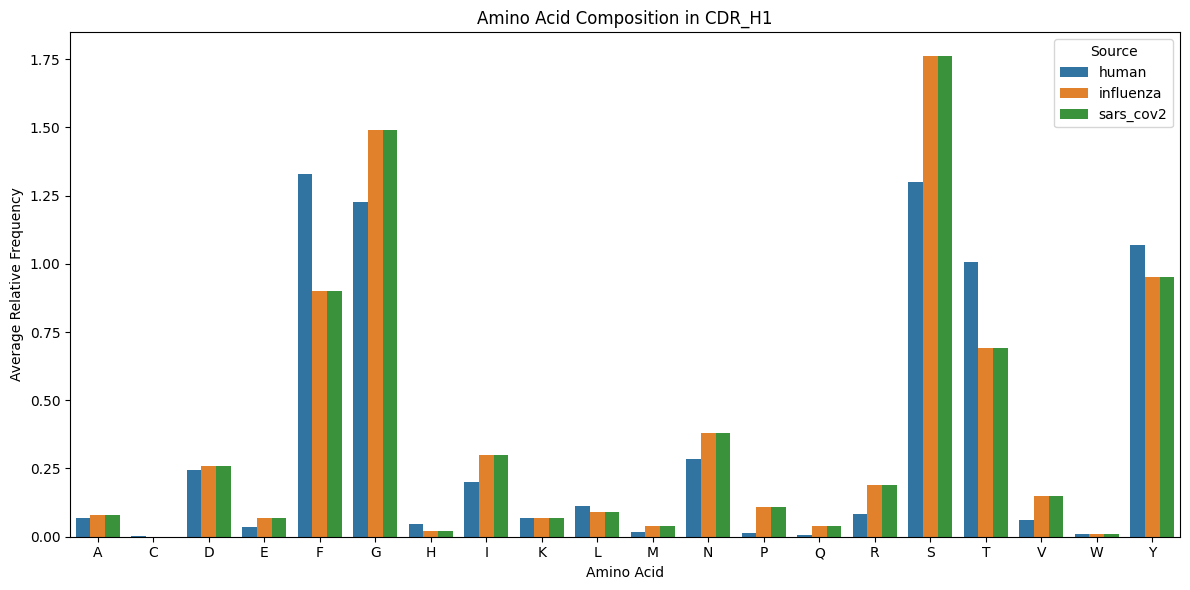


 Generating bar plot for CDR_H2...


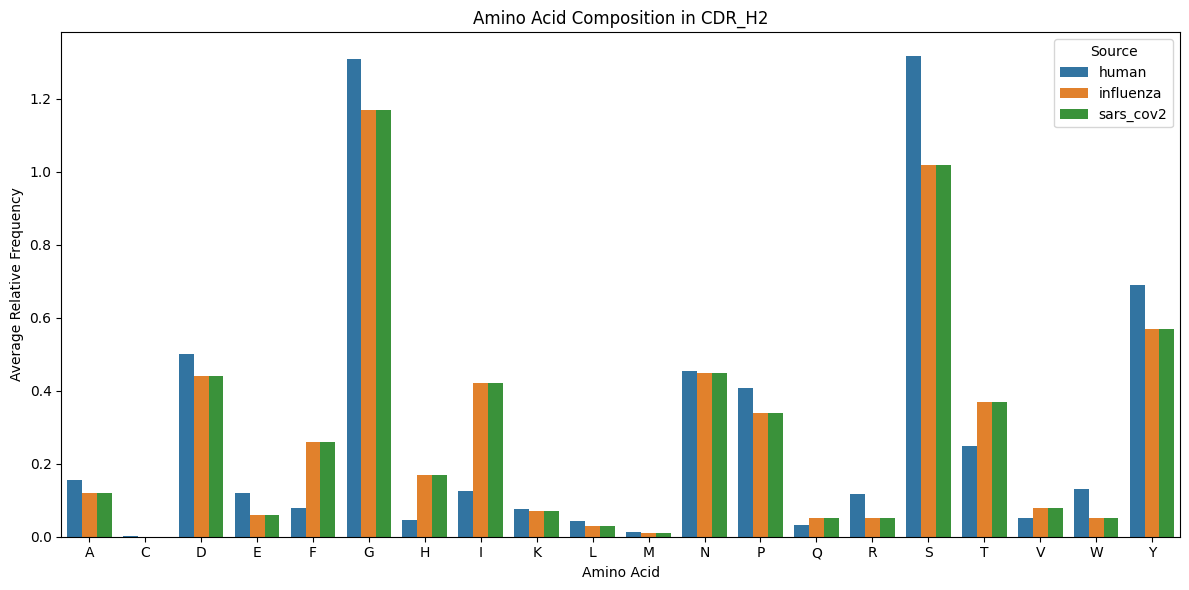


 Generating bar plot for CDR_H3...


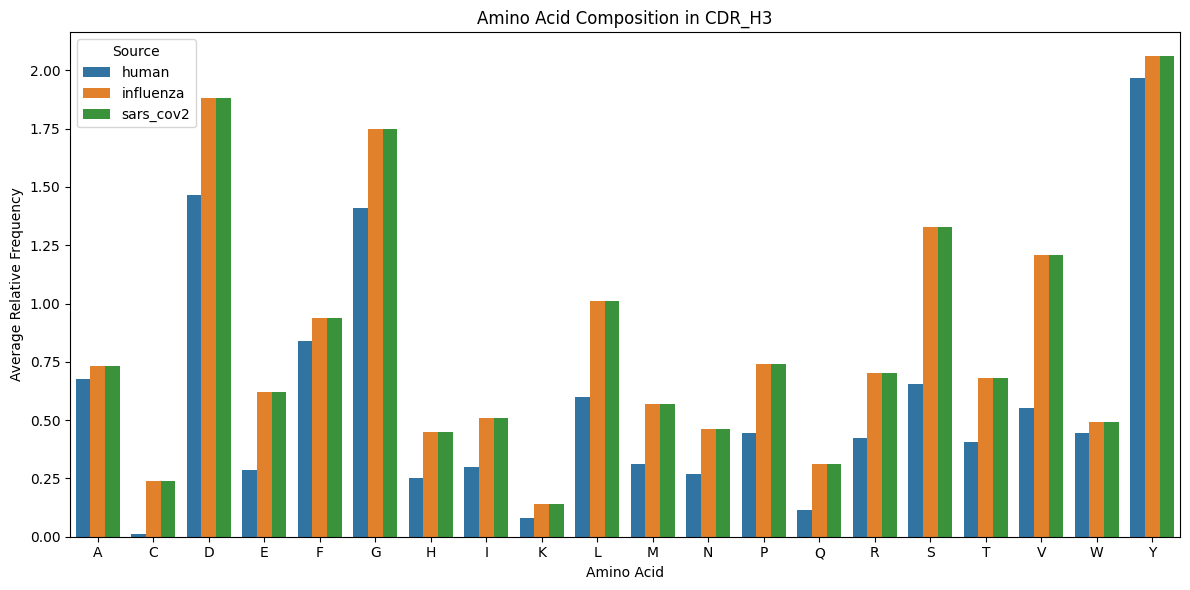

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the combined dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# Aminosäure-Reihenfolge (optional schön alphabetisch oder standardisiert)
aa_order = list("ACDEFGHIKLMNPQRSTVWY")

# Loop über CDRs
for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f"\n Generating bar plot for {cdr}...")

    # Die Spalten mit Aminosäureanteilen finden
    aa_columns = [col for col in df.columns if col.startswith(f"{cdr}_count_")]

    if not aa_columns:
        print(f" No count columns found for {cdr}")
        continue

    # Gruppieren nach Quelle und Mittelwert berechnen
    grouped = df.groupby("source")[aa_columns].mean()

    # In Long-Format bringen für Seaborn
    df_long = grouped.reset_index().melt(id_vars="source", var_name="AminoAcid", value_name="Frequency")

    # Nur den Aminosäure-Buchstaben extrahieren (z. B. aus 'CDR_H1_count_G' → 'G')
    df_long["AminoAcid"] = df_long["AminoAcid"].str.extract(f"{cdr}_count_(.)")

    # Sortiere nach definierter Aminosäure-Reihenfolge
    df_long["AminoAcid"] = pd.Categorical(df_long["AminoAcid"], categories=aa_order, ordered=True)
    df_long = df_long.sort_values("AminoAcid")

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_long, x="AminoAcid", y="Frequency", hue="source")
    plt.title(f"Amino Acid Composition in {cdr}")
    plt.xlabel("Amino Acid")
    plt.ylabel("Average Relative Frequency")
    plt.legend(title="Source")
    plt.tight_layout()
    plt.show()



 Generating bar plot for CDR_H1...


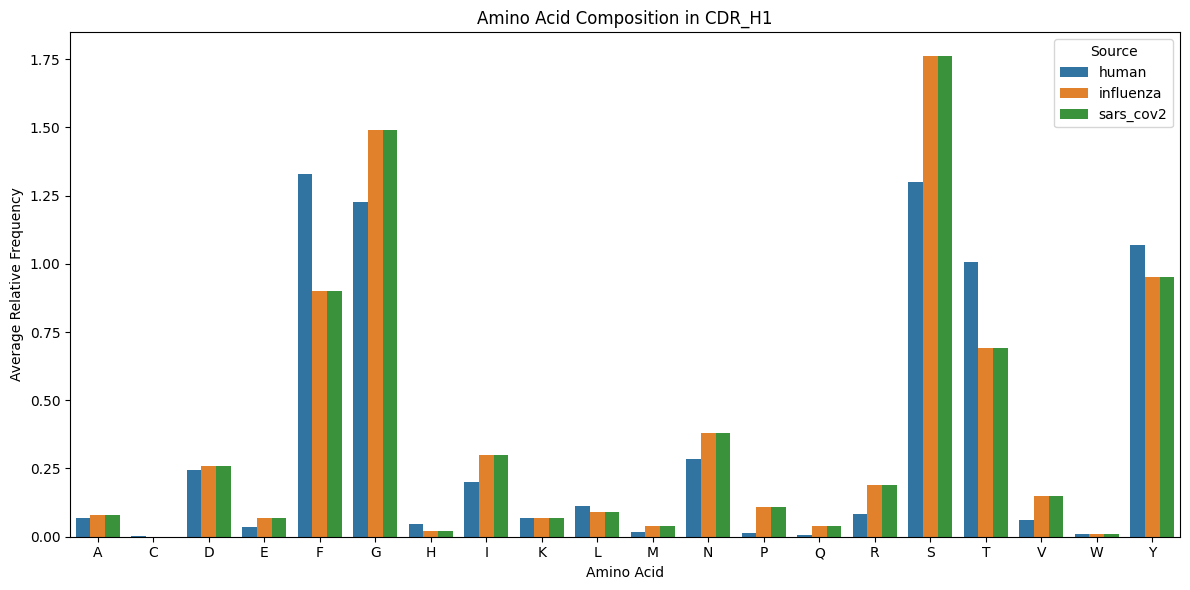


 Generating bar plot for CDR_H2...


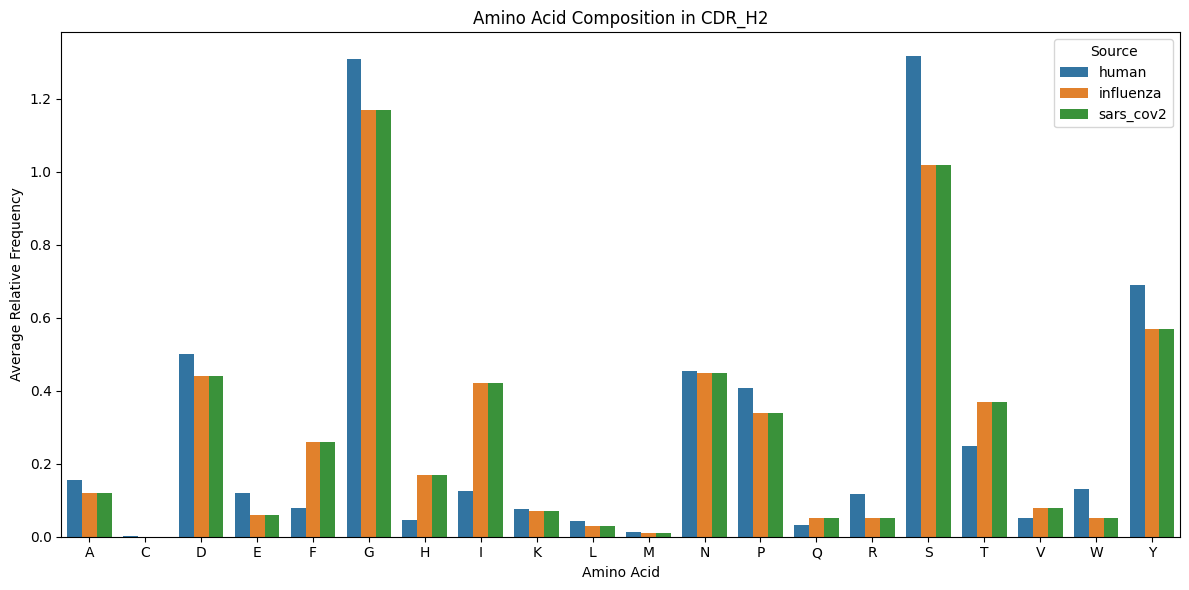


 Generating bar plot for CDR_H3...


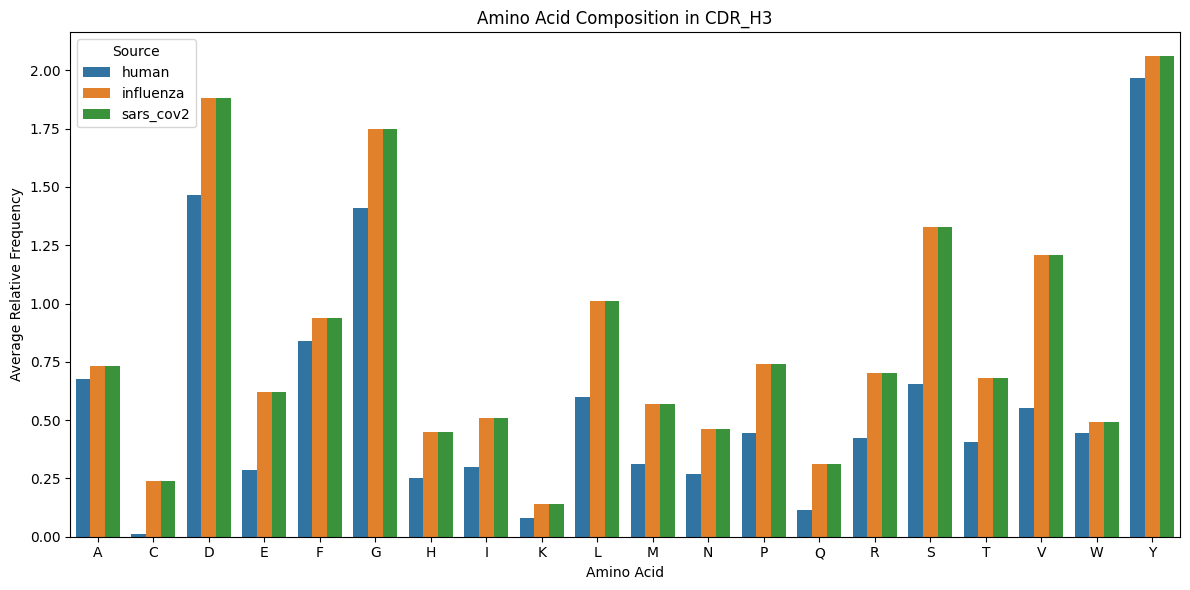

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the combined dataset
df = pd.read_csv("all_data.tsv", sep="\t")

# Aminosäure-Reihenfolge (optional schön alphabetisch oder standardisiert)
aa_order = list("ACDEFGHIKLMNPQRSTVWY")

# Loop über CDRs
for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f"\n Generating bar plot for {cdr}...")

    # Die Spalten mit Aminosäureanteilen finden
    aa_columns = [col for col in df.columns if col.startswith(f"{cdr}_count_")]

    if not aa_columns:
        print(f" No count columns found for {cdr}")
        continue

    # Gruppieren nach Quelle und Mittelwert berechnen
    grouped = df.groupby("source")[aa_columns].mean()

    # In Long-Format bringen für Seaborn
    df_long = grouped.reset_index().melt(id_vars="source", var_name="AminoAcid", value_name="Frequency")

    # Nur den Aminosäure-Buchstaben extrahieren (z. B. aus 'CDR_H1_count_G' → 'G')
    df_long["AminoAcid"] = df_long["AminoAcid"].str.extract(f"{cdr}_count_(.)")

    # Sortiere nach definierter Aminosäure-Reihenfolge
    df_long["AminoAcid"] = pd.Categorical(df_long["AminoAcid"], categories=aa_order, ordered=True)
    df_long = df_long.sort_values("AminoAcid")

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_long, x="AminoAcid", y="Frequency", hue="source")
    plt.title(f"Amino Acid Composition in {cdr}")
    plt.xlabel("Amino Acid")
    plt.ylabel("Average Relative Frequency")
    plt.legend(title="Source")
    plt.tight_layout()
    plt.show()
